NSE session initialized.

Progress: 0/197
Progress: 20/197
Progress: 40/197
Progress: 60/197
Progress: 80/197
Progress: 100/197
Progress: 120/197
Progress: 140/197
Progress: 160/197
Progress: 180/197

Total option observations: 327790

Strategy observations: 185

NIFTY STRADDLE / STRANGLE RESULTS

Observations: 184

Average Straddle Implied Move: 1.422 %
Average Strangle Implied Move: 0.332 %

Average Realized Move: 0.694 %

Average Straddle Edge: -0.728 %
Average Strangle Edge: 0.362 %

Straddle Sharpe: 18.334
Strangle Sharpe: -66.8

Straddle Max Drawdown: 0.0 %
Strangle Max Drawdown: nan %

Straddle Win Rate: 100.0 %
Strangle Win Rate: 1.63 %


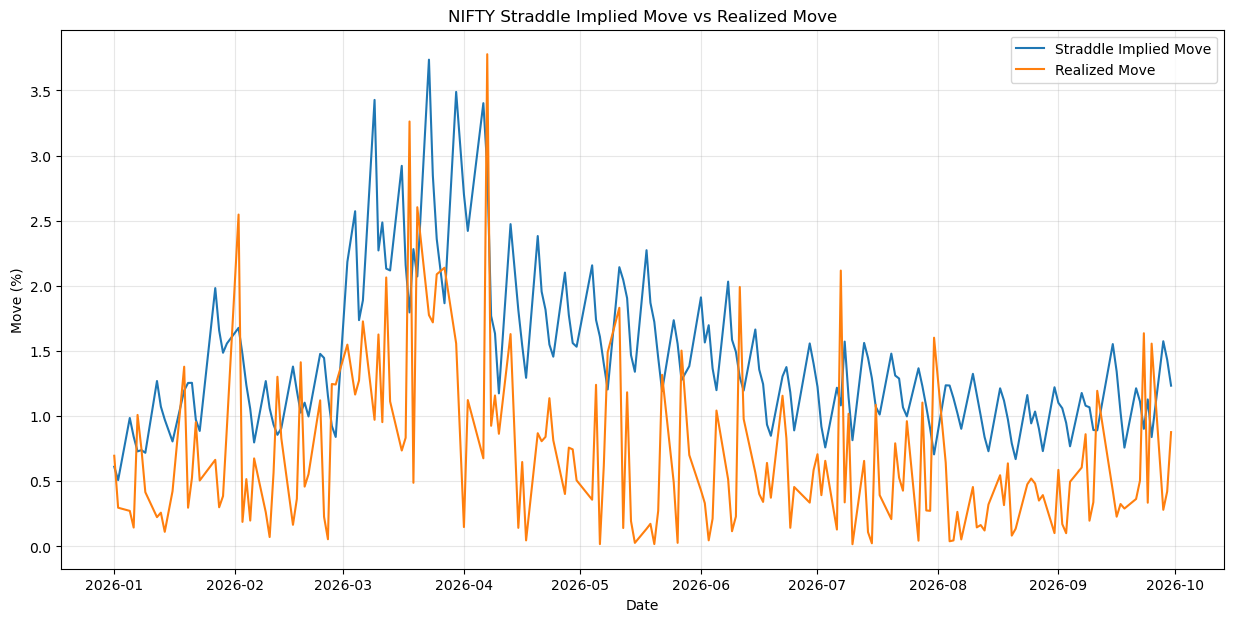

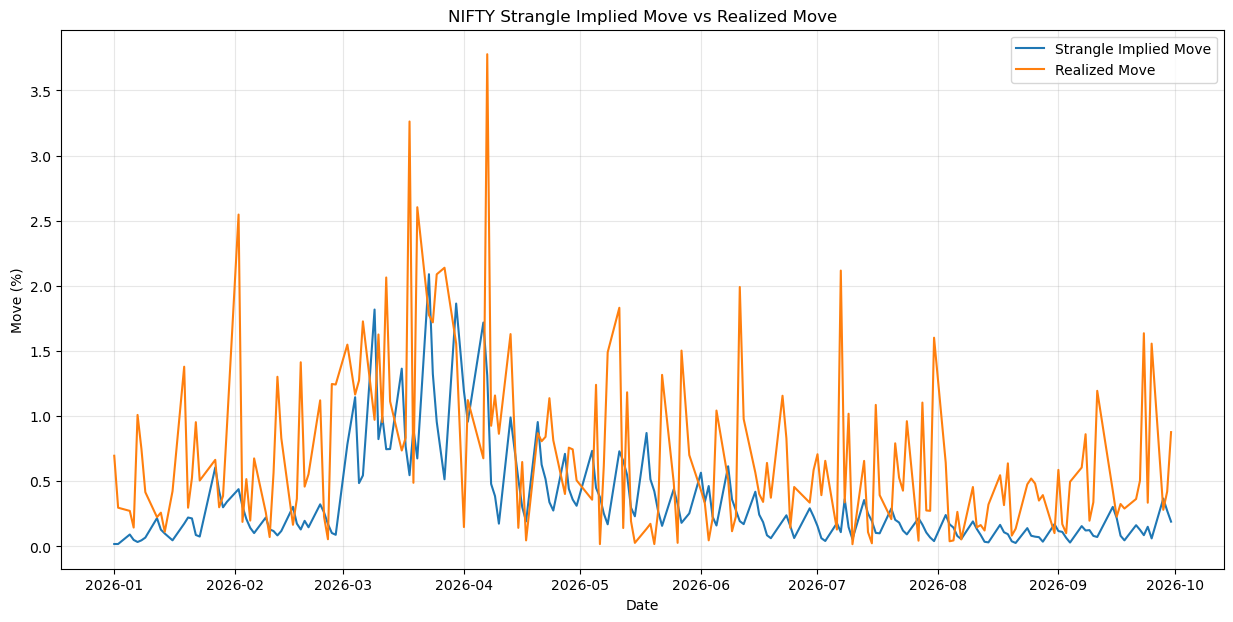

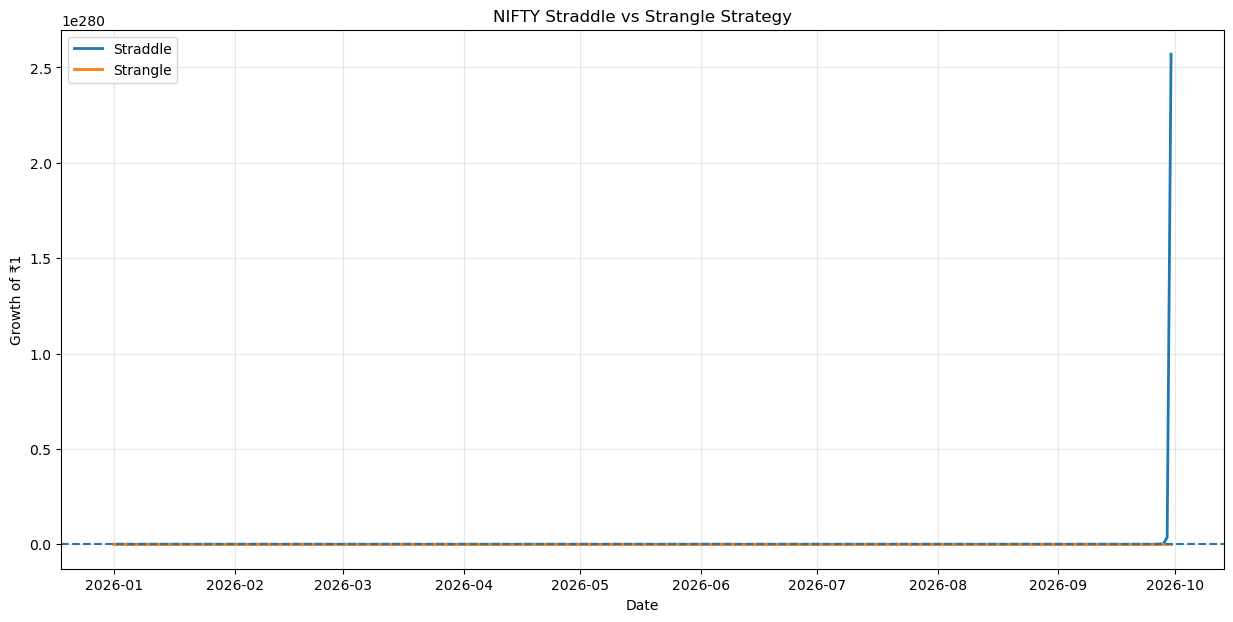

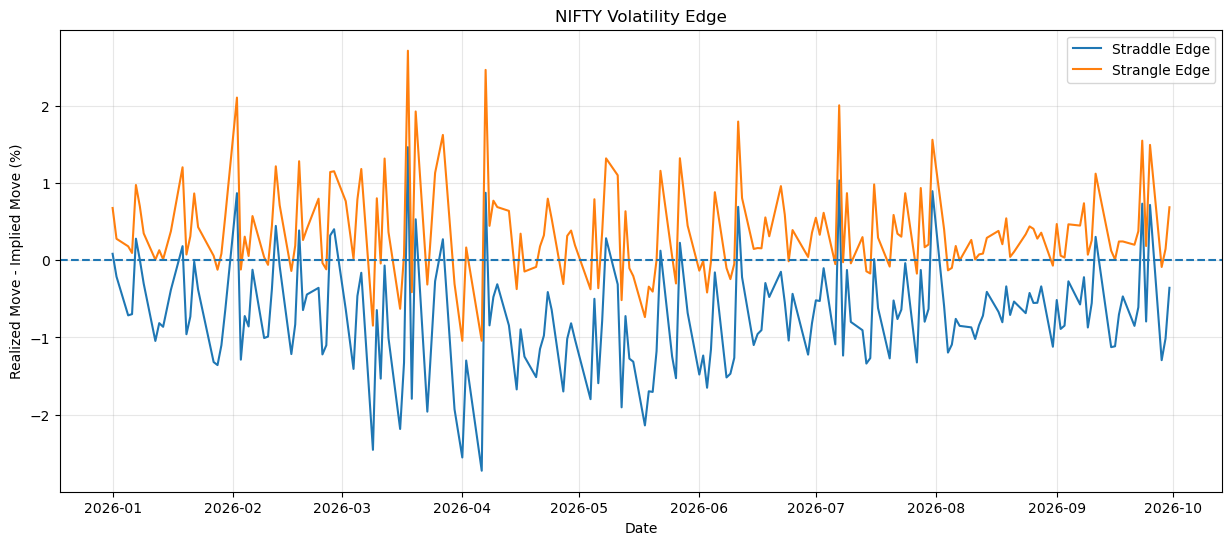


DTE ANALYSIS


,Straddle_Edge,Strangle_Edge,Straddle_Return,Strangle_Return
DTE,,,,
3,0.1216,1.1558,111.0275,-0.9473
4,-0.2911,0.6169,71.7990,-0.9749
5,-0.6004,0.4199,51.7553,-0.9825
6,-0.7920,0.3353,46.4980,-0.9077
7,-0.9610,0.2067,38.5442,-0.9814
8,-1.0704,0.1609,37.6606,-0.9660



Files saved:
NIFTY_Straddle_Strangle_Strategy.csv
NIFTY_Straddle_Strangle_DTE_Analysis.csv

PROJECT 5 COMPLETE
✓ ATM Straddle
✓ OTM Strangle
✓ Implied Move
✓ Realized Move
✓ Volatility Edge
✓ Strategy P&L
✓ Sharpe Ratio
✓ Maximum Drawdown
✓ Win Rate
✓ DTE Analysis
✓ Cumulative Performance


In [1]:
# ============================================================
# PROJECT 5
# NIFTY STRADDLE / STRANGLE VOLATILITY STRATEGY
#
# ATM STRADDLE
# OTM STRANGLE
# IMPLIED MOVE vs REALIZED MOVE
# BACKTEST + P&L + SHARPE + DRAWDOWN
# ============================================================

!pip -q install curl_cffi pandas numpy scipy matplotlib

import io
import zipfile
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from datetime import datetime
from scipy.stats import norm

from curl_cffi import requests

warnings.filterwarnings("ignore")

# ============================================================
# PARAMETERS
# ============================================================

START_DATE = "2026-01-01"

# How many days before expiry to enter
ENTRY_DTE = 7

# Hold the position for this many trading days
HOLD_DAYS = 1

# OTM distance for strangle
# 2% from ATM
STRANGLE_DISTANCE = 0.02

# Risk-free rate
RISK_FREE_RATE = 0.10

# Capital used for normalized strategy returns
CAPITAL = 100000

# ============================================================
# NSE SESSION
# ============================================================

session = requests.Session(
    impersonate="chrome"
)

session.headers.update({

    "Accept":
        "application/json, text/plain, */*",

    "Accept-Language":
        "en-US,en;q=0.9",

    "Referer":
        "https://www.nseindia.com/",

    "User-Agent":
        "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
        "AppleWebKit/537.36 "
        "(KHTML, like Gecko) "
        "Chrome/128.0.0.0 Safari/537.36"
})

session.get(
    "https://www.nseindia.com/",
    timeout=20
)

print("NSE session initialized.")

# ============================================================
# BHAVCOPY FUNCTION
# ============================================================

def download_bhavcopy(date):

    yyyymmdd = date.strftime(
        "%Y%m%d"
    )

    url = (
        "https://nsearchives.nseindia.com/"
        "content/fo/"
        f"BhavCopy_NSE_FO_0_0_0_"
        f"{yyyymmdd}_F_0000.csv.zip"
    )

    try:

        r = session.get(
            url,
            timeout=20
        )

        if r.status_code != 200:
            return None

        z = zipfile.ZipFile(
            io.BytesIO(
                r.content
            )
        )

        name = z.namelist()[0]

        return pd.read_csv(
            z.open(name)
        )

    except:

        return None


# ============================================================
# DOWNLOAD DAILY NIFTY OPTION DATA
# ============================================================

print(
    "\nDownloading NIFTY F&O data..."
)

start = pd.Timestamp(
    START_DATE
)

end = pd.Timestamp.today()

dates = pd.bdate_range(
    start,
    end
)

all_days = []

for i, date in enumerate(dates):

    if i % 20 == 0:

        print(
            f"Progress: {i}/{len(dates)}"
        )

    df = download_bhavcopy(
        date.to_pydatetime()
    )

    if df is None:
        continue

    df.columns = [
        str(c).strip()
        for c in df.columns
    ]

    # Required fields

    required = [
        "TckrSymb",
        "XpryDt",
        "StrkPric",
        "OptnTp"
    ]

    if not all(
        c in df.columns
        for c in required
    ):

        continue

    # NIFTY options only

    df = df[
        df["TckrSymb"]
        .astype(str)
        .str.upper()
        .eq("NIFTY")
    ].copy()

    if df.empty:
        continue

    # Options only

    df = df[
        df["OptnTp"]
        .astype(str)
        .str.upper()
        .isin(["CE", "PE"])
    ].copy()

    if df.empty:
        continue

    # Expiry

    df["XpryDt"] = pd.to_datetime(
        df["XpryDt"],
        errors="coerce"
    )

    # Strike

    df["StrkPric"] = pd.to_numeric(
        df["StrkPric"],
        errors="coerce"
    )

    # Underlying

    underlying = None

    for c in [
        "UndrlygPric",
        "UndrlygVal"
    ]:

        if c in df.columns:

            underlying = pd.to_numeric(
                df[c],
                errors="coerce"
            )

            break

    if underlying is None:
        continue

    df["Underlying"] = underlying

    # Close price

    close_col = None

    for c in [
        "ClsPric",
        "LastPric"
    ]:

        if c in df.columns:

            close_col = c
            break

    if close_col is None:
        continue

    df["OptionPrice"] = pd.to_numeric(
        df[close_col],
        errors="coerce"
    )

    # Keep useful fields

    df["Date"] = pd.Timestamp(date)

    df = df[
        [
            "Date",
            "XpryDt",
            "StrkPric",
            "OptnTp",
            "OptionPrice",
            "Underlying"
        ]
    ]

    all_days.append(df)


if len(all_days) == 0:

    raise Exception(
        "No NIFTY option data downloaded."
    )


options = pd.concat(
    all_days,
    ignore_index=True
)

options = options.dropna(
    subset=[
        "Date",
        "XpryDt",
        "StrkPric",
        "OptnTp",
        "OptionPrice",
        "Underlying"
    ]
)

options = options[
    options["OptionPrice"] > 0
]

print(
    "\nTotal option observations:",
    len(options)
)

# ============================================================
# BUILD DAILY EXPIRY STRUCTURE
# ============================================================

options["DTE"] = (
    options["XpryDt"]
    -
    options["Date"]
).dt.days

options = options[
    options["DTE"] > 0
]

# ============================================================
# SELECT NEAREST EXPIRY AROUND ENTRY DTE
# ============================================================

strategy_rows = []

unique_dates = sorted(
    options["Date"].unique()
)

for date in unique_dates:

    day = options[
        options["Date"] == date
    ].copy()

    if day.empty:
        continue

    # Find expiry closest to ENTRY_DTE
    expiries = (
        day[
            ["XpryDt", "DTE"]
        ]
        .drop_duplicates()
    )

    if expiries.empty:
        continue

    expiries["distance"] = (
        abs(
            expiries["DTE"]
            -
            ENTRY_DTE
        )
    )

    expiry_row = (
        expiries
        .sort_values(
            [
                "distance",
                "DTE"
            ]
        )
        .iloc[0]
    )

    expiry = expiry_row["XpryDt"]

    dte = int(
        expiry_row["DTE"]
    )

    chain = day[
        day["XpryDt"] == expiry
    ].copy()

    if chain.empty:
        continue

    # --------------------------------------------------------
    # ATM STRIKE
    # --------------------------------------------------------

    spot = (
        chain["Underlying"]
        .median()
    )

    strikes = (
        chain["StrkPric"]
        .dropna()
        .unique()
    )

    if len(strikes) == 0:
        continue

    atm = min(
        strikes,
        key=lambda x:
            abs(x - spot)
    )

    # --------------------------------------------------------
    # ATM CALL
    # --------------------------------------------------------

    ce = chain[
        (
            chain["OptnTp"]
            .astype(str)
            .str.upper()
            == "CE"
        )
        &
        (
            chain["StrkPric"]
            == atm
        )
    ]

    # --------------------------------------------------------
    # ATM PUT
    # --------------------------------------------------------

    pe = chain[
        (
            chain["OptnTp"]
            .astype(str)
            .str.upper()
            == "PE"
        )
        &
        (
            chain["StrkPric"]
            == atm
        )
    ]

    if ce.empty or pe.empty:
        continue

    ce_price = float(
        ce.iloc[0]["OptionPrice"]
    )

    pe_price = float(
        pe.iloc[0]["OptionPrice"]
    )

    # ========================================================
    # ATM STRADDLE
    # ========================================================

    straddle_price = (
        ce_price
        +
        pe_price
    )

    # ========================================================
    # STRANGLE STRIKES
    # ========================================================

    put_target = (
        spot
        *
        (
            1
            -
            STRANGLE_DISTANCE
        )
    )

    call_target = (
        spot
        *
        (
            1
            +
            STRANGLE_DISTANCE
        )
    )

    put_strike = min(
        strikes,
        key=lambda x:
            abs(x - put_target)
    )

    call_strike = min(
        strikes,
        key=lambda x:
            abs(x - call_target)
    )

    otm_put = chain[
        (
            chain["OptnTp"]
            .astype(str)
            .str.upper()
            == "PE"
        )
        &
        (
            chain["StrkPric"]
            == put_strike
        )
    ]

    otm_call = chain[
        (
            chain["OptnTp"]
            .astype(str)
            .str.upper()
            == "CE"
        )
        &
        (
            chain["StrkPric"]
            == call_strike
        )
    ]

    if (
        otm_put.empty
        or
        otm_call.empty
    ):
        continue

    put_price = float(
        otm_put.iloc[0]["OptionPrice"]
    )

    call_price = float(
        otm_call.iloc[0]["OptionPrice"]
    )

    strangle_price = (
        put_price
        +
        call_price
    )

    # ========================================================
    # IMPLIED MOVES
    # ========================================================

    straddle_implied_move = (
        straddle_price
        /
        spot
    )

    strangle_implied_move = (
        strangle_price
        /
        spot
    )

    strategy_rows.append({

        "Date":
            pd.Timestamp(date),

        "Expiry":
            expiry,

        "DTE":
            dte,

        "Spot":
            spot,

        "ATM":
            atm,

        "ATM_Call":
            ce_price,

        "ATM_Put":
            pe_price,

        "Straddle":
            straddle_price,

        "Put_Strike":
            put_strike,

        "Put_Price":
            put_price,

        "Call_Strike":
            call_strike,

        "Call_Price":
            call_price,

        "Strangle":
            strangle_price,

        "Straddle_Implied_Move":
            straddle_implied_move * 100,

        "Strangle_Implied_Move":
            strangle_implied_move * 100

    })


strategy = pd.DataFrame(
    strategy_rows
)

strategy = strategy.sort_values(
    "Date"
)

print(
    "\nStrategy observations:",
    len(strategy)
)

# ============================================================
# REALIZED MOVEMENT
# ============================================================

strategy["Next_Day_Spot"] = (
    strategy["Spot"]
    .shift(-HOLD_DAYS)
)

strategy["Realized_Move"] = (
    (
        strategy["Next_Day_Spot"]
        -
        strategy["Spot"]
    )
    /
    strategy["Spot"]
    *
    100
)

strategy["Abs_Realized_Move"] = (
    strategy["Realized_Move"]
    .abs()
)

# ============================================================
# VOLATILITY EDGE
# ============================================================

strategy["Straddle_Edge"] = (

    strategy["Abs_Realized_Move"]

    -

    strategy[
        "Straddle_Implied_Move"
    ]

)

strategy["Strangle_Edge"] = (

    strategy["Abs_Realized_Move"]

    -

    strategy[
        "Strangle_Implied_Move"
    ]

)

# ============================================================
# STRADDLE PAYOFF
# ============================================================

strategy["Straddle_Realized_PnL"] = (

    strategy["Abs_Realized_Move"]
    *
    strategy["Spot"]

    -

    strategy["Straddle"]

)

# ============================================================
# STRANGLE PAYOFF
# ============================================================

strategy["Strangle_Realized_PnL"] = (

    np.maximum(
        strategy["Next_Day_Spot"]
        -
        strategy["Call_Strike"],
        0
    )

    +

    np.maximum(
        strategy["Put_Strike"]
        -
        strategy["Next_Day_Spot"],
        0
    )

    -

    strategy["Strangle"]

)

# ============================================================
# NORMALIZED RETURNS
# ============================================================

strategy["Straddle_Return"] = (

    strategy["Straddle_Realized_PnL"]
    /
    strategy["Straddle"]

)

strategy["Strangle_Return"] = (

    strategy["Strangle_Realized_PnL"]
    /
    strategy["Strangle"]

)

# ============================================================
# CLEAN DATA
# ============================================================

strategy = strategy.replace(
    [np.inf, -np.inf],
    np.nan
)

strategy = strategy.dropna(
    subset=[
        "Straddle_Return",
        "Strangle_Return"
    ]
)

# ============================================================
# CUMULATIVE RETURNS
# ============================================================

strategy[
    "Straddle_Cumulative"
] = (

    1
    +
    strategy[
        "Straddle_Return"
    ]

).cumprod()

strategy[
    "Strangle_Cumulative"
] = (

    1
    +
    strategy[
        "Strangle_Return"
    ]

).cumprod()

# ============================================================
# MAX DRAWDOWN
# ============================================================

def max_drawdown(series):

    peak = series.cummax()

    drawdown = (
        series
        /
        peak
        -
        1
    )

    return drawdown.min()


# ============================================================
# SHARPE
# ============================================================

def sharpe_ratio(returns):

    if returns.std() == 0:
        return np.nan

    return (
        returns.mean()
        /
        returns.std()
        *
        np.sqrt(252)
    )


# ============================================================
# PERFORMANCE SUMMARY
# ============================================================

straddle_sharpe = sharpe_ratio(
    strategy[
        "Straddle_Return"
    ]
)

strangle_sharpe = sharpe_ratio(
    strategy[
        "Strangle_Return"
    ]
)

straddle_dd = max_drawdown(
    strategy[
        "Straddle_Cumulative"
    ]
)

strangle_dd = max_drawdown(
    strategy[
        "Strangle_Cumulative"
    ]
)

straddle_win = (
    strategy[
        "Straddle_Return"
    ]
    > 0
).mean()

strangle_win = (
    strategy[
        "Strangle_Return"
    ]
    > 0
).mean()

# ============================================================
# PRINT RESULTS
# ============================================================

print(
    "\n=============================================="
)

print(
    "NIFTY STRADDLE / STRANGLE RESULTS"
)

print(
    "=============================================="
)

print(
    "\nObservations:",
    len(strategy)
)

print(
    "\nAverage Straddle Implied Move:",
    round(
        strategy[
            "Straddle_Implied_Move"
        ].mean(),
        3
    ),
    "%"
)

print(
    "Average Strangle Implied Move:",
    round(
        strategy[
            "Strangle_Implied_Move"
        ].mean(),
        3
    ),
    "%"
)

print(
    "\nAverage Realized Move:",
    round(
        strategy[
            "Abs_Realized_Move"
        ].mean(),
        3
    ),
    "%"
)

print(
    "\nAverage Straddle Edge:",
    round(
        strategy[
            "Straddle_Edge"
        ].mean(),
        3
    ),
    "%"
)

print(
    "Average Strangle Edge:",
    round(
        strategy[
            "Strangle_Edge"
        ].mean(),
        3
    ),
    "%"
)

print(
    "\nStraddle Sharpe:",
    round(
        straddle_sharpe,
        3
    )
)

print(
    "Strangle Sharpe:",
    round(
        strangle_sharpe,
        3
    )
)

print(
    "\nStraddle Max Drawdown:",
    round(
        straddle_dd * 100,
        2
    ),
    "%"
)

print(
    "Strangle Max Drawdown:",
    round(
        strangle_dd * 100,
        2
    ),
    "%"
)

print(
    "\nStraddle Win Rate:",
    round(
        straddle_win * 100,
        2
    ),
    "%"
)

print(
    "Strangle Win Rate:",
    round(
        strangle_win * 100,
        2
    ),
    "%"
)

# ============================================================
# IMPLIED VS REALIZED MOVE
# ============================================================

plt.figure(
    figsize=(15,7)
)

plt.plot(
    strategy["Date"],
    strategy[
        "Straddle_Implied_Move"
    ],
    label="Straddle Implied Move",
    linewidth=1.5
)

plt.plot(
    strategy["Date"],
    strategy[
        "Abs_Realized_Move"
    ],
    label="Realized Move",
    linewidth=1.5
)

plt.xlabel(
    "Date"
)

plt.ylabel(
    "Move (%)"
)

plt.title(
    "NIFTY Straddle Implied Move vs Realized Move"
)

plt.grid(
    alpha=0.3
)

plt.legend()

plt.show()

# ============================================================
# STRANGLE IMPLIED VS REALIZED
# ============================================================

plt.figure(
    figsize=(15,7)
)

plt.plot(
    strategy["Date"],
    strategy[
        "Strangle_Implied_Move"
    ],
    label="Strangle Implied Move",
    linewidth=1.5
)

plt.plot(
    strategy["Date"],
    strategy[
        "Abs_Realized_Move"
    ],
    label="Realized Move",
    linewidth=1.5
)

plt.xlabel(
    "Date"
)

plt.ylabel(
    "Move (%)"
)

plt.title(
    "NIFTY Strangle Implied Move vs Realized Move"
)

plt.grid(
    alpha=0.3
)

plt.legend()

plt.show()

# ============================================================
# CUMULATIVE PERFORMANCE
# ============================================================

plt.figure(
    figsize=(15,7)
)

plt.plot(
    strategy["Date"],
    strategy[
        "Straddle_Cumulative"
    ],
    label="Straddle",
    linewidth=2
)

plt.plot(
    strategy["Date"],
    strategy[
        "Strangle_Cumulative"
    ],
    label="Strangle",
    linewidth=2
)

plt.axhline(
    1,
    linestyle="--"
)

plt.xlabel(
    "Date"
)

plt.ylabel(
    "Growth of ₹1"
)

plt.title(
    "NIFTY Straddle vs Strangle Strategy"
)

plt.grid(
    alpha=0.3
)

plt.legend()

plt.show()

# ============================================================
# IMPLIED MOVE EDGE
# ============================================================

plt.figure(
    figsize=(15,6)
)

plt.plot(
    strategy["Date"],
    strategy[
        "Straddle_Edge"
    ],
    label="Straddle Edge"
)

plt.plot(
    strategy["Date"],
    strategy[
        "Strangle_Edge"
    ],
    label="Strangle Edge"
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel(
    "Date"
)

plt.ylabel(
    "Realized Move - Implied Move (%)"
)

plt.title(
    "NIFTY Volatility Edge"
)

plt.grid(
    alpha=0.3
)

plt.legend()

plt.show()

# ============================================================
# DTE ANALYSIS
# ============================================================

dte_analysis = (
    strategy
    .groupby("DTE")
    .agg({

        "Straddle_Edge":
            "mean",

        "Strangle_Edge":
            "mean",

        "Straddle_Return":
            "mean",

        "Strangle_Return":
            "mean"

    })
)

print(
    "\n=============================================="
)

print(
    "DTE ANALYSIS"
)

print(
    "=============================================="
)

display(
    dte_analysis.round(4)
)

# ============================================================
# EXPORT
# ============================================================

strategy.to_csv(
    "NIFTY_Straddle_Strangle_Strategy.csv",
    index=False
)

dte_analysis.to_csv(
    "NIFTY_Straddle_Strangle_DTE_Analysis.csv"
)

print(
    "\nFiles saved:"
)

print(
    "NIFTY_Straddle_Strangle_Strategy.csv"
)

print(
    "NIFTY_Straddle_Strangle_DTE_Analysis.csv"
)

# ============================================================
# ==================

# ============================================================

print(
    "\n=============================================="
)

print(
    "PROJECT 5 COMPLETE"
)

print(
    "=============================================="
)

print(
    "✓ ATM Straddle"
)

print(
    "✓ OTM Strangle"
)

print(
    "✓ Implied Move"
)

print(
    "✓ Realized Move"
)

print(
    "✓ Volatility Edge"
)

print(
    "✓ Strategy P&L"
)

print(
    "✓ Sharpe Ratio"
)

print(
    "✓ Maximum Drawdown"
)

print(
    "✓ Win Rate"
)

print(
    "✓ DTE Analysis"
)

print(
    "✓ Cumulative Performance"
)

print(
    "=============================================="
)